<a href="https://colab.research.google.com/github/twillixa/PPS/blob/main/Main_1_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from pulp import (
    LpProblem, LpMinimize, LpVariable, LpInteger,
    lpSum, value, PULP_CBC_CMD
)
import ipywidgets as widgets
from IPython.display import display, HTML

##Data loading

In [ ]:





REPO_URL = "https://github.com/twillixa/PPS"
CSV_FILENAME = "Demand_data.csv"
RAW_URL = f"https://raw.githubusercontent.com/twillixa/PPS/main/{CSV_FILENAME}"

demand_df = pd.read_csv(RAW_URL)
demand_df.columns = [
    "Day",
    "3235 Movement",
    "Oystersteel Case",
    "Sapphire Crystal",
    "Jubilee Bracelet",
    "Lubricant Oil",
    "Diamond Marker",
    "Gold Crown",
]

component_names = [c for c in demand_df.columns if c != "Day"]

# Per-component summary statistics (daily)
demand_stats = {}
for comp in component_names:
    series = demand_df[comp]
    demand_stats[comp] = {
        "mean_daily": round(series.mean(), 4),
        "std_daily":  round(series.std(ddof=1), 4),
        "min_daily":  int(series.min()),
        "max_daily":  int(series.max()),
        "total":      int(series.sum()),
    }

print(f"Loaded '{CSV_FILENAME}' from {REPO_URL}")
print(f"{len(demand_df)} days, {len(component_names)} components\n")
print(f"  {'Component':<20} {'Mean/day':>9} {'Std/day':>9} {'Min':>5} {'Max':>5} {'Total':>7}")
print(f"  {'-'*58}")
for comp, s in demand_stats.items():
    print(f"  {comp:<20} {s['mean_daily']:>9.2f} {s['std_daily']:>9.2f} "
          f"{s['min_daily']:>5} {s['max_daily']:>5} {s['total']:>7}")

Loaded 'Demand_data.csv' from https://github.com/twillixa/PPS
365 days, 7 components

  Component             Mean/day   Std/day   Min   Max   Total
  ----------------------------------------------------------
  3235 Movement            14.26      3.56     5    25    5205
  Oystersteel Case         15.18      4.28     4    29    5540
  Sapphire Crystal         14.21      3.59     4    25    5187
  Jubilee Bracelet          8.02      0.99     5    12    2926
  Lubricant Oil           150.72     41.18    40   298   55014
  Diamond Marker           47.81      5.09    35    63   17449
  Gold Crown                8.01      3.03     0    17    2922


In [ ]:

# ------------------------------------------------------------
# AGGREGATE PLANNING PARAMETERS (Table 1)
# ------------------------------------------------------------

planning_horizon = 12  # months (January to December)

# Workforce & Production
initial_workers = 90          # workers at start of January
production_rate = 10          # watches per worker per month

# Inventory
starting_inventory = 900      # watches (beginning of January)
ending_inventory_target = 1000  # watches (end of December)
holding_cost = 1000           # CHF per watch per month

# Labor Costs
regular_wage = 7000           # CHF per worker per month
hiring_cost = 50000           # CHF per worker hired
layoff_cost = 25000           # CHF per worker laid off

# Overtime
overtime_allowance = 0.20     # up to 20% extra capacity
overtime_cost_multiplier = 2  # 2x regular wage
overtime_months = [3, 5, 9, 12]  # March, May, September, December

# Subcontracting
subcontracting_limit = 300    # watches per month (max)
subcontracting_cost = 15000   # CHF per watch
subcontracting_months = [6, 7, 10, 12]  # June, July, October, December

# Derived: overtime cost per worker per month (when overtime is used)
overtime_cost_per_worker = regular_wage * overtime_cost_multiplier  # CHF

# ------------------------------------------------------------
# FORECASTED MONTHLY DEMAND (Table 2)
# ------------------------------------------------------------

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

demand = {
    "Jan": 900,
    "Feb": 950,
    "Mar": 1200,
    "Apr": 1050,
    "May": 1100,
    "Jun": 1300,
    "Jul": 1250,
    "Aug": 1100,
    "Sep": 1300,
    "Oct": 1450,
    "Nov": 1500,
    "Dec": 1700,
}

demand_list = [demand[m] for m in months]
total_annual_demand = sum(demand_list)  # total watches needed

# ------------------------------------------------------------
# INVENTORY MANAGEMENT PARAMETERS (Table 3)
# ------------------------------------------------------------
# Components for Aurelius SA watches
# Keys: lead_time (days), holding_cost (CHF/unit/month),
#       ordering_cost (CHF), shelf_life (days), supplier

components = {
    "3235 Movement": {
        "lead_time_days": 60,
        "holding_cost_per_unit_month": 1200,  # CHF/unit/month
        "ordering_cost": 9000,                # CHF per order
        "shelf_life_days": 365,
        "supplier": "Supplier",
    },
    "Oystersteel Case": {
        "lead_time_days": 45,
        "holding_cost_per_unit_month": 400,
        "ordering_cost": 7000,
        "shelf_life_days": 505,
        "supplier": "Internal",
    },
    "Sapphire Crystal": {
        "lead_time_days": 30,
        "holding_cost_per_unit_month": 200,
        "ordering_cost": 4000,
        "shelf_life_days": 365,
        "supplier": "Internal",
    },
    "Jubilee Bracelet": {
        "lead_time_days": 35,
        "holding_cost_per_unit_month": 220,
        "ordering_cost": 3500,
        "shelf_life_days": 1460,
        "supplier": "Internal",
    },
    "Lubricant Oil": {
        "lead_time_days": 14,
        "holding_cost_per_unit_month": 50,
        "ordering_cost": 1000,
        "shelf_life_days": 730,
        "supplier": "Supplier DE",
    },
    "Diamond Marker": {
        "lead_time_days": 21,
        "holding_cost_per_unit_month": 900,
        "ordering_cost": 6000,
        "shelf_life_days": 1825,
        "supplier": "Supplier CH",
    },
    "Gold Crown": {
        "lead_time_days": 40,
        "holding_cost_per_unit_month": 350,
        "ordering_cost": 5000,
        "shelf_life_days": 730,
        "supplier": "Supplier CH",
    },
}

# ------------------------------------------------------------
# SUMMARY PRINTOUT
# ------------------------------------------------------------

if __name__ == "__main__":
    print("=" * 55)
    print("AURELIUS SA — PROJECT PART 1 DATA SUMMARY")
    print("=" * 55)

    print("\n--- Aggregate Planning ---")
    print(f"  Planning horizon      : {planning_horizon} months")
    print(f"  Initial workers       : {initial_workers}")
    print(f"  Production rate       : {production_rate} watches/worker/month")
    print(f"  Starting inventory    : {starting_inventory} watches")
    print(f"  Ending target         : {ending_inventory_target} watches")
    print(f"  Holding cost          : {holding_cost} CHF/watch/month")
    print(f"  Regular wage          : {regular_wage} CHF/worker/month")
    print(f"  Hiring cost           : {hiring_cost} CHF/worker")
    print(f"  Layoff cost           : {layoff_cost} CHF/worker")
    print(f"  Overtime allowance    : {overtime_allowance*100:.0f}% extra capacity")
    print(f"  Overtime months       : {[months[m-1] for m in overtime_months]}")
    print(f"  Subcontracting limit  : {subcontracting_limit} watches/month")
    print(f"  Subcontracting cost   : {subcontracting_cost} CHF/watch")
    print(f"  Subcontracting months : {[months[m-1] for m in subcontracting_months]}")

    print("\n--- Monthly Demand Forecast ---")
    print(f"  {'Month':<6} {'Demand':>8}")
    print(f"  {'-'*16}")
    for m, d in demand.items():
        print(f"  {m:<6} {d:>8}")
    print(f"  {'-'*16}")
    print(f"  {'TOTAL':<6} {total_annual_demand:>8}")

    print("\n--- Inventory Components ---")
    print(f"  {'Component':<20} {'LT(d)':>6} {'Hold':>6} {'Order':>7} "
          f"{'Shelf(d)':>9} {'Supplier':<12}")
    print(f"  {'-'*65}")
    for name, p in components.items():
        print(f"  {name:<20} {p['lead_time_days']:>6} "
              f"{p['holding_cost_per_unit_month']:>6} "
              f"{p['ordering_cost']:>7} "
              f"{p['shelf_life_days']:>9} "
              f"{p['supplier']:<12}")

    print("\nData loaded successfully. Ready for analysis.")


AURELIUS SA — PROJECT PART 1 DATA SUMMARY

--- Aggregate Planning ---
  Planning horizon      : 12 months
  Initial workers       : 90
  Production rate       : 10 watches/worker/month
  Starting inventory    : 900 watches
  Ending target         : 1000 watches
  Holding cost          : 1000 CHF/watch/month
  Regular wage          : 7000 CHF/worker/month
  Hiring cost           : 50000 CHF/worker
  Layoff cost           : 25000 CHF/worker
  Overtime allowance    : 20% extra capacity
  Overtime months       : ['Mar', 'May', 'Sep', 'Dec']
  Subcontracting limit  : 300 watches/month
  Subcontracting cost   : 15000 CHF/watch
  Subcontracting months : ['Jun', 'Jul', 'Oct', 'Dec']

--- Monthly Demand Forecast ---
  Month    Demand
  ----------------
  Jan         900
  Feb         950
  Mar        1200
  Apr        1050
  May        1100
  Jun        1300
  Jul        1250
  Aug        1100
  Sep        1300
  Oct        1450
  Nov        1500
  Dec        1700
  ----------------
  TOTAL    

##Model 1

In [ ]:
# ── Model 1: Base MILP with strategy switch (chase / level) ──────────────────



def solve_model1(strategy="level", verbose=False):
    """
    Model 1 – no overtime, no subcontracting.

    strategy : "level" → workforce is fixed to a single constant W*
               "chase" → workforce can change freely each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model1_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    # chase: W[t] free each month  |  level: all W[t] forced equal via W_star
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T          # same variable reused → forces constant workforce
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H = [LpVariable(f"H_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    F = [LpVariable(f"F_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    I = [LpVariable(f"I_{t}", lowBound=0)                for t in range(T)]

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker * W[t] for t in range(T))
      + lpSum(hire_cost       * H[t] for t in range(T))
      + lpSum(layoff_cost     * F[t] for t in range(T))
      + lpSum(holding_cost    * I[t] for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W = W0 if t == 0 else W[t-1]
        prev_I = I0 if t == 0 else I[t-1]

        # Workforce balance: always enforced (for level, H/F only fire at t=0 if needed)
        prob += W[t] == prev_W + H[t] - F[t],                          f"workforce_{t}"
        # Inventory balance
        prob += I[t] == prev_I + prod_per_worker * W[t] - demand_list[t],   f"inventory_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers   = [int(round(value(W[t]))) for t in range(T)]
    hired     = [int(round(value(H[t]))) for t in range(T)]
    fired     = [int(round(value(F[t]))) for t in range(T)]
    inventory = [value(I[t])             for t in range(T)]

    wage_c   = [wage_per_worker * workers[t]   for t in range(T)]
    hire_c   = [hire_cost       * hired[t]     for t in range(T)]
    layoff_c = [layoff_cost     * fired[t]     for t in range(T)]
    inv_c    = [holding_cost    * inventory[t] for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Produced":       [prod_per_worker * w for w in workers],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":        strategy,
        "Status":          prob.status,
        "Total Wage":      sum(wage_c),
        "Total Hiring":    sum(hire_c),
        "Total Layoff":    sum(layoff_c),
        "Total Inventory": sum(inv_c),
        "Grand Total":     sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(inv_c),
    }

    return df, summary


In [ ]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

# Define global variables used by solve_model1
T            = planning_horizon
I0           = starting_inventory
I_T          = ending_inventory_target
W0           = initial_workers
prod_per_worker = production_rate
wage_per_worker = regular_wage
hire_cost    = hiring_cost
layoff_cost  = layoff_cost
holding_cost = holding_cost
MONTH_NAMES  = months
# Use the list version so integer indexing works inside solve_model1
demand_list  = [demand[m] for m in months]

for strat in ("level", "chase"):
    df, s = solve_model1(strategy=strat)
    print(f"\n{'═'*60}")
    print(f"  MODEL 1 – {strat.upper()} STRATEGY")
    print(f"{'═'*60}")
    display(df)
    print(f"\n── Cost Summary (CHF) ──")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")



════════════════════════════════════════════════════════════
  MODEL 1 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Produced,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,Jan,125,35,0,1250,900,1250,875000,1750000,0,"1,250,000","3,875,000"
1,Feb,125,0,0,1250,950,1550,875000,0,0,"1,550,000","2,425,000"
2,Mar,125,0,0,1250,1200,1600,875000,0,0,"1,600,000","2,475,000"
3,Apr,125,0,0,1250,1050,1800,875000,0,0,"1,800,000","2,675,000"
4,May,125,0,0,1250,1100,1950,875000,0,0,"1,950,000","2,825,000"
5,Jun,125,0,0,1250,1300,1900,875000,0,0,"1,900,000","2,775,000"
6,Jul,125,0,0,1250,1250,1900,875000,0,0,"1,900,000","2,775,000"
7,Aug,125,0,0,1250,1100,2050,875000,0,0,"2,050,000","2,925,000"
8,Sep,125,0,0,1250,1300,2000,875000,0,0,"2,000,000","2,875,000"
9,Oct,125,0,0,1250,1450,1800,875000,0,0,"1,800,000","2,675,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      10,500,000
  Total Hiring        :       1,750,000
  Total Layoff        :               0
  Total Inventory     :      20,450,000
  Grand Total         :      32,700,000

════════════════════════════════════════════════════════════
  MODEL 1 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Produced,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,Jan,80,0,10,800,900,800,560000,0,250000,"800,000","1,610,000"
1,Feb,80,0,0,800,950,650,560000,0,0,"650,000","1,210,000"
2,Mar,80,0,0,800,1200,250,560000,0,0,"250,000","810,000"
3,Apr,80,0,0,800,1050,0,560000,0,0,0,"560,000"
4,May,115,35,0,1150,1100,50,805000,1750000,0,"50,000","2,605,000"
5,Jun,125,10,0,1250,1300,0,875000,500000,0,0,"1,375,000"
6,Jul,125,0,0,1250,1250,0,875000,0,0,0,"875,000"
7,Aug,125,0,0,1250,1100,150,875000,0,0,"150,000","1,025,000"
8,Sep,125,0,0,1250,1300,100,875000,0,0,"100,000","975,000"
9,Oct,185,60,0,1850,1450,500,1295000,3000000,0,"500,000","4,795,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      10,430,000
  Total Hiring        :       5,250,000
  Total Layoff        :         250,000
  Total Inventory     :       4,350,000
  Grand Total         :      20,280,000


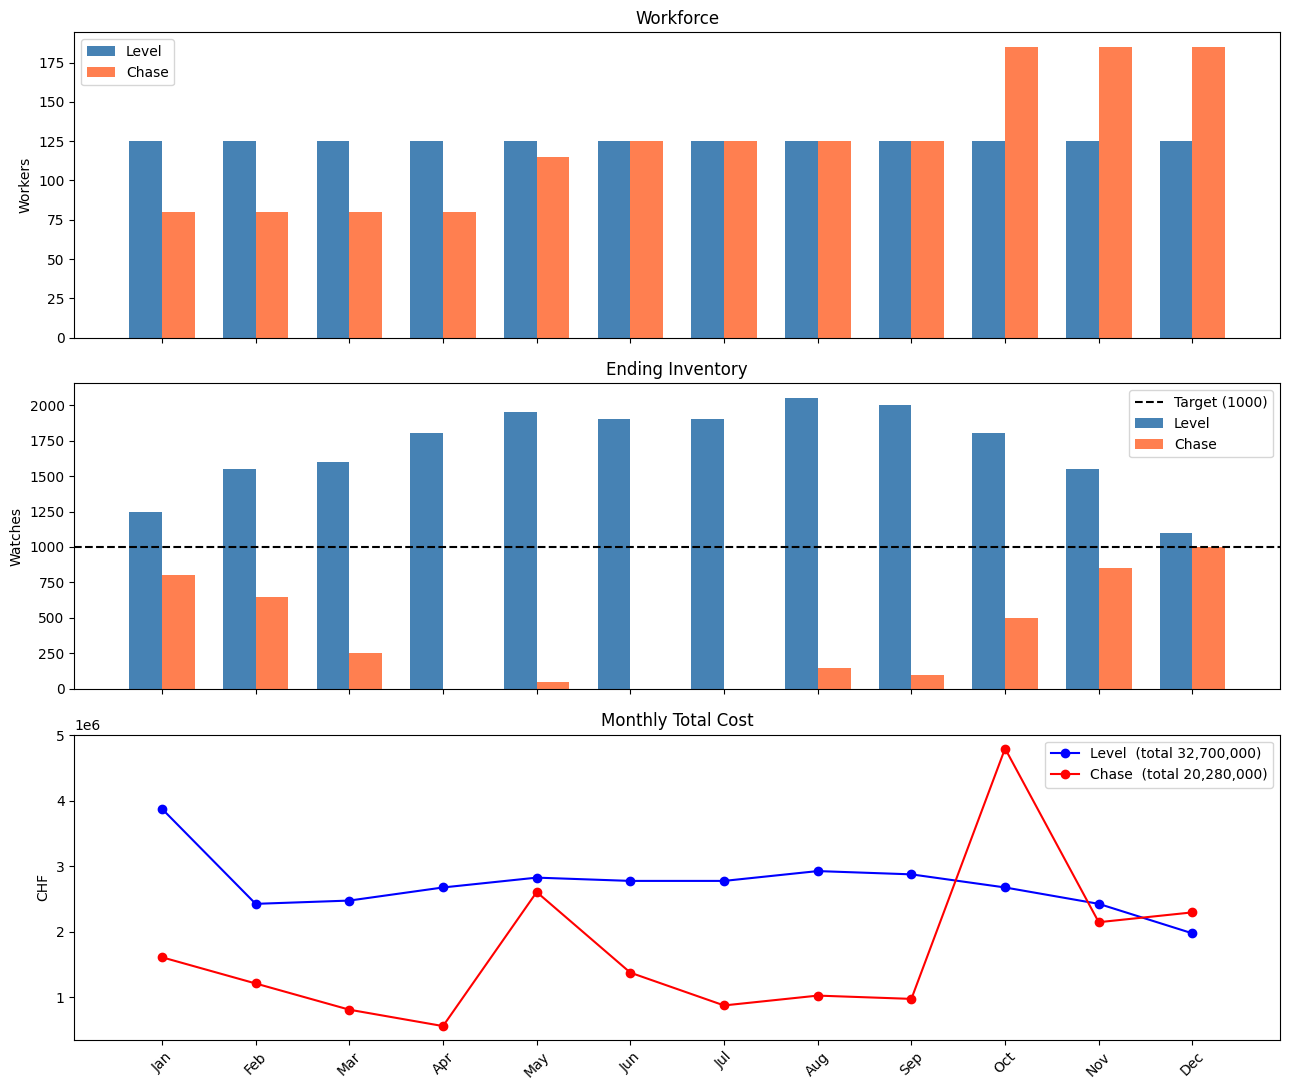

In [ ]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model1(strategy="level")
df_chase, s_chase = solve_model1(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

##Model 2

In [ ]:
def solve_model2(strategy="level", overtime_allowance_param=0.20, verbose=False):
    """
    Model 2 – Includes overtime production.

    strategy : "level" → workforce is fixed to a single constant W*
               "chase" → workforce can change freely each month
    overtime_allowance_param: Maximum overtime allowance as a percentage of regular capacity.
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model2_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T          # same variable reused → forces constant workforce
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H = [LpVariable(f"H_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    F = [LpVariable(f"F_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    I = [LpVariable(f"I_{t}", lowBound=0)                for t in range(T)]
    W_ot = [LpVariable(f"W_ot_{t}", lowBound=0, cat=LpInteger) for t in range(T)] # New: Overtime workers

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker * W[t] for t in range(T))
      + lpSum(hire_cost       * H[t] for t in range(T))
      + lpSum(layoff_cost     * F[t] for t in range(T))
      + lpSum(holding_cost    * I[t] for t in range(T))
      + lpSum(overtime_cost_per_worker * W_ot[t] for t in range(T)) # New: Overtime cost
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W = W0 if t == 0 else W[t-1]
        prev_I = I0 if t == 0 else I[t-1]

        # Workforce balance
        prob += W[t] == prev_W + H[t] - F[t],                          f"workforce_{t}"

        # Inventory balance (updated for overtime production)
        prob += I[t] == prev_I + prod_per_worker * W[t] + prod_per_worker * W_ot[t] - demand_list[t], f"inventory_{t}"

        # Overtime constraint: W_ot cannot exceed a percentage of regular W
        prob += W_ot[t] <= overtime_allowance_param * W[t], f"overtime_limit_{t}"

        # Overtime only allowed in specific months (1-indexed)
        if (t + 1) not in overtime_months:
            prob += W_ot[t] == 0, f"no_overtime_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers   = [int(round(value(W[t]))) for t in range(T)]
    hired     = [int(round(value(H[t]))) for t in range(T)]
    fired     = [int(round(value(F[t]))) for t in range(T)]
    inventory = [value(I[t])             for t in range(T)]
    ot_workers = [int(round(value(W_ot[t]))) for t in range(T)] # New: Overtime workers

    wage_c   = [wage_per_worker * workers[t]   for t in range(T)]
    hire_c   = [hire_cost       * hired[t]     for t in range(T)]
    layoff_c = [layoff_cost     * fired[t]     for t in range(T)]
    inv_c    = [holding_cost    * inventory[t] for t in range(T)]
    ot_c     = [overtime_cost_per_worker * ot_workers[t] for t in range(T)] # New: Overtime cost

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Overtime Workers": ot_workers, # New column
        "Produced":       [prod_per_worker * w for w in workers],
        "Overtime Production": [prod_per_worker * ow for ow in ot_workers], # New column
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "Inventory Cost": inv_c,
        "Overtime Cost":  ot_c, # New column
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+inv_c[t]+ot_c[t] for t in range(T)], # Updated total cost
    })

    summary = {
        "Strategy":        strategy,
        "Status":          prob.status,
        "Total Wage":      sum(wage_c),
        "Total Hiring":    sum(hire_c),
        "Total Layoff":    sum(layoff_c),
        "Total Inventory": sum(inv_c),
        "Total Overtime":  sum(ot_c), # New summary item
        "Grand Total":     sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(inv_c)+sum(ot_c), # Updated grand total
    }

    return df, summary

In [ ]:
overtime_slider = widgets.FloatSlider(
    value=0.20,
    min=0.0,
    max=0.5,
    step=0.05,
    description='Overtime Allowance (%):',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.0%',
)

print("FloatSlider for overtime allowance created.")

FloatSlider for overtime allowance created.


In [ ]:
def run_model2_interactive(overtime_allowance_param):
    pd.set_option("display.float_format", "{:,.0f}".format)

    # Solve Model 2 for both strategies with the given overtime allowance
    df_level_m2, s_level_m2 = solve_model2(strategy="level", overtime_allowance_param=overtime_allowance_param)
    df_chase_m2, s_chase_m2 = solve_model2(strategy="chase", overtime_allowance_param=overtime_allowance_param)

    print(f"\n{'═'*60}")
    print(f"  MODEL 2 – LEVEL STRATEGY (Overtime Allowance: {overtime_allowance_param:.0%})")
    print(f"{'═'*60}")
    display(df_level_m2)
    print(f"\n── Cost Summary (CHF) ──")
    for k, v in s_level_m2.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")

    print(f"\n{'═'*60}")
    print(f"  MODEL 2 – CHASE STRATEGY (Overtime Allowance: {overtime_allowance_param:.0%})")
    print(f"{'═'*60}")
    display(df_chase_m2)
    print(f"\n── Cost Summary (CHF) ──")
    for k, v in s_chase_m2.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")

    # ── Side-by-side comparison plot ──────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
    x  = range(T)
    w  = 0.35
    x1 = [i - w/2 for i in x]
    x2 = [i + w/2 for i in x]

    # Workers
    axes[0].bar(x1, df_level_m2["Workers"], width=w, color="steelblue", label="Level")
    axes[0].bar(x2, df_chase_m2["Workers"], width=w, color="coral",     label="Chase")
    axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

    # Inventory
    axes[1].bar(x1, df_level_m2["End Inventory"], width=w, color="steelblue", label="Level")
    axes[1].bar(x2, df_chase_m2["End Inventory"], width=w, color="coral",     label="Chase")
    axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
    axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

    # Monthly total cost
    axes[2].plot(x, df_level_m2["Total Cost"], "bo-", label=f"Level  (total {s_level_m2['Grand Total']:,.0f})")
    axes[2].plot(x, df_chase_m2["Total Cost"], "ro-", label=f"Chase  (total {s_chase_m2['Grand Total']:,.0f})")
    axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
    axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

interactive_output = widgets.interactive_output(run_model2_interactive, {'overtime_allowance_param': overtime_slider})

display(overtime_slider, interactive_output)


FloatSlider(value=0.2, continuous_update=False, description='Overtime Allowance (%):', max=0.5, readout_format…

Output()

##Model 3

##Model 4


## Graphs & stuff

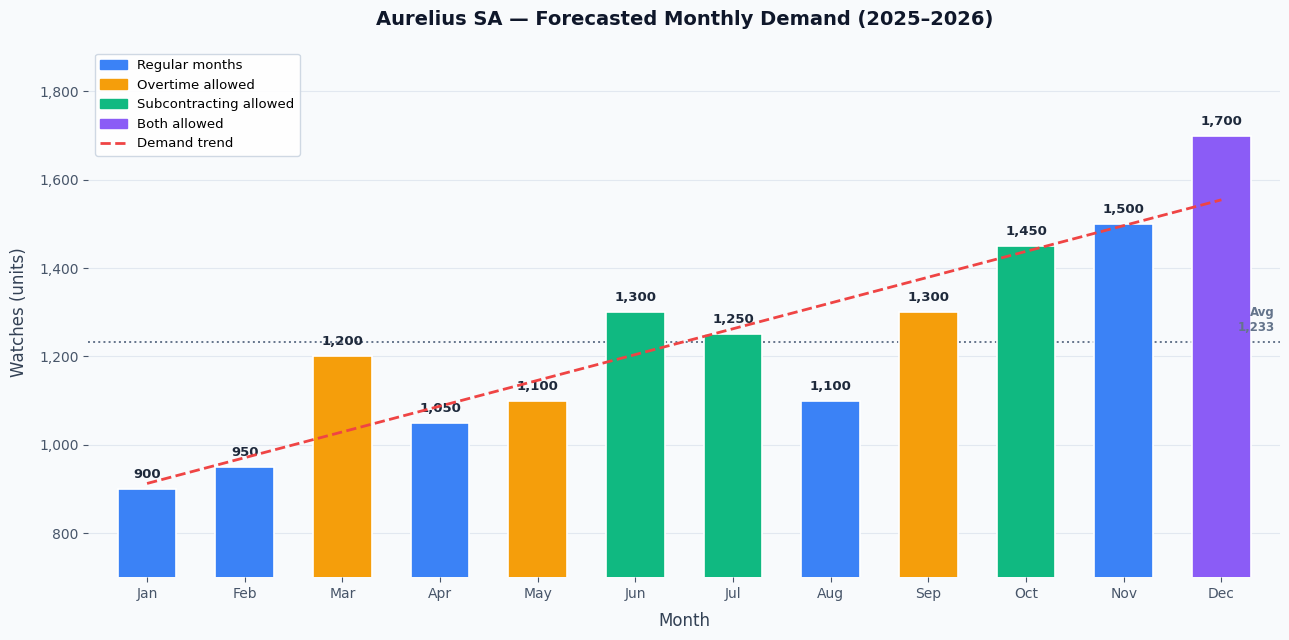

In [ ]:

# ── Forecasted Monthly Demand Chart ──────────────────────────────────────────

# Overtime and subcontracting months (1-indexed)
overtime_months_set      = {3, 5, 9, 12}   # Mar, May, Sep, Dec
subcontracting_months_set = {6, 7, 10, 12} # Jun, Jul, Oct, Dec

# Color each bar
colors = []
for i in range(1, 13):
    if i in overtime_months_set and i in subcontracting_months_set:
        colors.append("#8B5CF6")   # purple = both
    elif i in overtime_months_set:
        colors.append("#F59E0B")   # amber = overtime
    elif i in subcontracting_months_set:
        colors.append("#10B981")   # green = subcontracting
    else:
        colors.append("#3B82F6")   # blue = regular

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# Bars
bars = ax.bar(MONTH_NAMES, demand_list, color=colors, width=0.6,
              edgecolor="white", linewidth=1.2, zorder=3)

# Trend line
x_num = np.arange(len(MONTH_NAMES))
z = np.polyfit(x_num, demand_list, 1)
p = np.poly1d(z)
ax.plot(MONTH_NAMES, p(x_num), color="#EF4444", linewidth=2,
        linestyle="--", zorder=4, label="Trend")

# Value labels on bars
for bar, val in zip(bars, demand_list):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 18,
            f"{val:,}", ha="center", va="bottom",
            fontsize=9.5, fontweight="bold", color="#1E293B")

# Reference line: average demand
avg = sum(demand_list) / len(demand_list)
ax.axhline(avg, color="#64748B", linewidth=1.4, linestyle=":", zorder=2)
ax.text(11.55, avg + 18, f"Avg\n{avg:,.0f}",
        ha="right", va="bottom", fontsize=8.5,
        color="#64748B", fontweight="bold")

# Axes styling
ax.set_ylim(700, 1900)
ax.set_xlim(-0.6, 11.6)
ax.set_xlabel("Month", fontsize=12, color="#334155", labelpad=8)
ax.set_ylabel("Watches (units)", fontsize=12, color="#334155", labelpad=8)
ax.set_title("Aurelius SA — Forecasted Monthly Demand (2025–2026)",
             fontsize=14, fontweight="bold", color="#0F172A", pad=16)

ax.tick_params(colors="#475569", labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, color="#E2E8F0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Legend
legend_items = [
    mpatches.Patch(color="#3B82F6", label="Regular months"),
    mpatches.Patch(color="#F59E0B", label="Overtime allowed"),
    mpatches.Patch(color="#10B981", label="Subcontracting allowed"),
    mpatches.Patch(color="#8B5CF6", label="Both allowed"),
    plt.Line2D([0], [0], color="#EF4444", linewidth=2,
               linestyle="--", label="Demand trend"),
]
ax.legend(handles=legend_items, loc="upper left",
          frameon=True, framealpha=0.9, fontsize=9.5,
          edgecolor="#CBD5E1")

plt.tight_layout()
plt.show()
